In [59]:
# 乱数の固定
from tensorflow.keras import utils
utils.set_random_seed(0)

In [60]:
# データの取得
import tensorflow as tf
data = tf.keras.datasets.cifar10.load_data()

In [61]:
import tensorflow as tf
from tensorflow import keras

In [62]:
data

((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [63]:
(x_train, y_train), (x_test, y_test) = data

In [64]:
# データの確認
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [65]:
# 各変数を構成する数値データの最大値と最小値の確認
import numpy as np
print(np.amin(x_train), np.amax(x_train))
print(np.amin(y_train), np.max(y_train))
print(np.amin(x_test), np.amax(x_test))
print(np.amin(y_test), np.amax(y_test))

0 255
0 9
0 255
0 9


array([[[154, 177, 187],
        [126, 137, 136],
        [105, 104,  95],
        ...,
        [ 91,  95,  71],
        [ 87,  90,  71],
        [ 79,  81,  70]],

       [[140, 160, 169],
        [145, 153, 154],
        [125, 125, 118],
        ...,
        [ 96,  99,  78],
        [ 77,  80,  62],
        [ 71,  73,  61]],

       [[140, 155, 164],
        [139, 146, 149],
        [115, 115, 112],
        ...,
        [ 79,  82,  64],
        [ 68,  70,  55],
        [ 67,  69,  55]],

       ...,

       [[175, 167, 166],
        [156, 154, 160],
        [154, 160, 170],
        ...,
        [ 42,  34,  36],
        [ 61,  53,  57],
        [ 93,  83,  91]],

       [[165, 154, 128],
        [156, 152, 130],
        [159, 161, 142],
        ...,
        [103,  93,  96],
        [123, 114, 120],
        [131, 121, 131]],

       [[163, 148, 120],
        [158, 148, 122],
        [163, 156, 133],
        ...,
        [143, 133, 139],
        [143, 134, 142],
        [143, 133, 144]]], dtype=uint8)
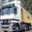

In [66]:
x_train[1]

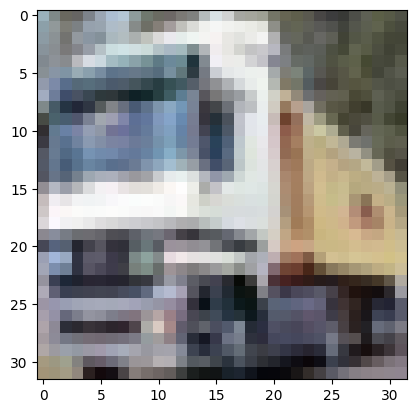

In [67]:
# x_train[1]のデータを可視化
import matplotlib.pyplot as plt
plt.imshow(x_train[1])

In [68]:
y_train[1]

array([9], dtype=uint8)

In [69]:
# スケーリング
# 画像を 0-1 に正規化
x_train = x_train / 255.0
x_test = x_test / 255.0

# フラット化
x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

In [70]:
# One-hotベクトル化
from tensorflow.keras import utils
y_train = utils.to_categorical(y_train)
y_test = utils.to_categorical(y_test)

In [71]:
y_train[2]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [72]:
# ニュートラルネットワーク構造の定義
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [73]:
model = Sequential()

In [75]:

num_classes = 10

model = keras.Sequential([
    keras.layers.Input(shape=(32*32*3,)),  # 3072次元
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

In [76]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# 損失関数、最適化方法、評価指数の設定
model.compile(loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

In [78]:
history = model.fit(x_train, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2817 - loss: 2.0046 - val_accuracy: 0.3818 - val_loss: 1.7430
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3834 - loss: 1.7220 - val_accuracy: 0.3900 - val_loss: 1.6716
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4142 - loss: 1.6330 - val_accuracy: 0.4310 - val_loss: 1.6061
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4354 - loss: 1.5782 - val_accuracy: 0.4370 - val_loss: 1.5800
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4499 - loss: 1.5396 - val_accuracy: 0.4470 - val_loss: 1.5780
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4625 - loss: 1.5095 - val_accuracy: 0.4512 - val_loss: 1.5506
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.4703 - loss: 1.4883 - val_accuracy: 0.4574 - val_loss: 1.5325
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4783 - loss: 1

In [79]:
history.history

{'accuracy': [0.32357779145240784,
  0.3898000121116638,
  0.4163777828216553,
  0.4374000132083893,
  0.4507777690887451,
  0.46239998936653137,
  0.4691999852657318,
  0.47868889570236206,
  0.48428890109062195,
  0.49042221903800964],
 'loss': [1.877563238143921,
  1.7000553607940674,
  1.6245614290237427,
  1.5719335079193115,
  1.5362157821655273,
  1.5070003271102905,
  1.4852991104125977,
  1.4636399745941162,
  1.4470773935317993,
  1.4336473941802979],
 'val_accuracy': [0.38179999589920044,
  0.38999998569488525,
  0.4309999942779541,
  0.43700000643730164,
  0.44699999690055847,
  0.451200008392334,
  0.45739999413490295,
  0.460999995470047,
  0.4702000021934509,
  0.46459999680519104],
 'val_loss': [1.7429585456848145,
  1.671607255935669,
  1.606144666671753,
  1.5799500942230225,
  1.5780404806137085,
  1.5506269931793213,
  1.5325078964233398,
  1.5241239070892334,
  1.5031851530075073,
  1.523578405380249]}

In [80]:
import pandas as pd
df = pd.DataFrame(history.history)
df

,accuracy,loss,val_accuracy,val_loss
0,0.323578,1.877563,0.3818,1.742959
1,0.389800,1.700055,0.3900,1.671607
2,0.416378,1.624561,0.4310,1.606145
3,0.437400,1.571934,0.4370,1.579950
4,0.450778,1.536216,0.4470,1.578040
5,0.462400,1.507000,0.4512,1.550627
6,0.469200,1.485299,0.4574,1.532508
7,0.478689,1.463640,0.4610,1.524124
8,0.484289,1.447077,0.4702,1.503185
9,0.490422,1.433647,0.4646,1.523578


<Axes: >

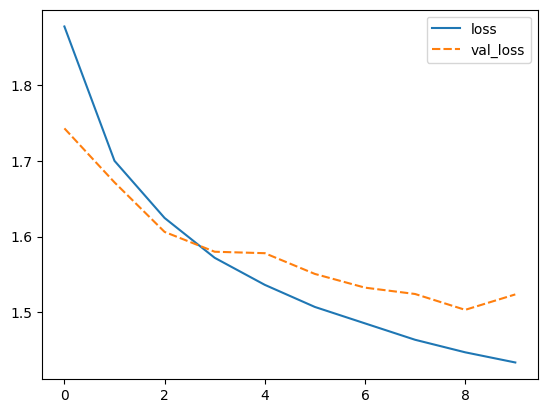

In [81]:
import seaborn as sns
sns.lineplot(data=df[['loss', 'val_loss']])

<Axes: >

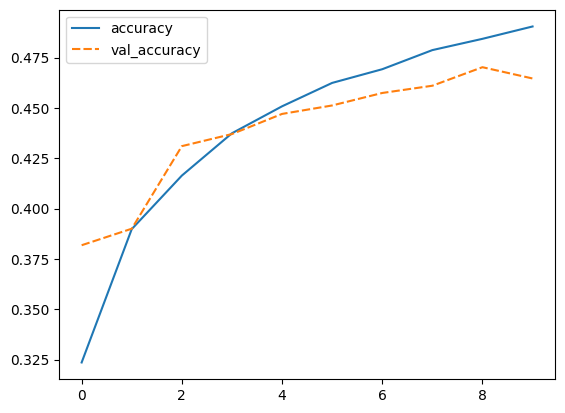

In [82]:
sns.lineplot(data=df[['accuracy', 'val_accuracy']])

In [85]:
utils.set_random_seed(0)

model = Sequential()
model.add(Flatten(input_shape=(32*32*3,)))  # 3072次元
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

history = model.fit(x_train, y_train,
    batch_size=32,
    epochs=7,
    validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2797 - loss: 1.9968 - val_accuracy: 0.3780 - val_loss: 1.7553
Epoch 2/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.3798 - loss: 1.7177 - val_accuracy: 0.4024 - val_loss: 1.6747
Epoch 3/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.4159 - loss: 1.6314 - val_accuracy: 0.4272 - val_loss: 1.6194
Epoch 4/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4373 - loss: 1.5765 - val_accuracy: 0.4296 - val_loss: 1.5980
Epoch 5/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4535 - loss: 1.5370 - val_accuracy: 0.4390 - val_loss: 1.5737
Epoch 6/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.4617 - loss: 1.5065 - val_accuracy: 0.4534 - val_loss: 1.5367
Epoch 7/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4697 - loss: 1.4849 - val_accuracy: 0.4558 - val_loss: 1.5347


In [86]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4629 - loss: 1.5114


[1.5198924541473389, 0.4609000086784363]

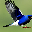

In [87]:
# 未知データの予測
from tensorflow.keras.preprocessing.image import load_img
unknown_img = load_img('/content/unknown_cifar.jpg', target_size=(32, 32))
unknown_img

In [88]:
from tensorflow.keras.preprocessing.image import img_to_array
unknown_array = img_to_array(unknown_img)

In [89]:
unknown_array = unknown_array/255

In [90]:
unknown_array.shape

(32, 32, 3)

In [91]:
print(x_train.shape, x_test.shape)

(50000, 3072) (10000, 3072)


In [95]:
unknown_array = unknown_array.reshape((1, 32*32*3))
unknown_array.shape

(1, 3072)

In [96]:
result = model.predict(unknown_array)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[1.0570688e-01, 1.1476577e-02, 2.6948160e-01, 1.7449690e-01,
        2.8408566e-03, 2.7238226e-01, 2.0444026e-02, 1.1172971e-01,
        9.4457955e-06, 3.1431753e-02]], dtype=float32)

<Axes: >

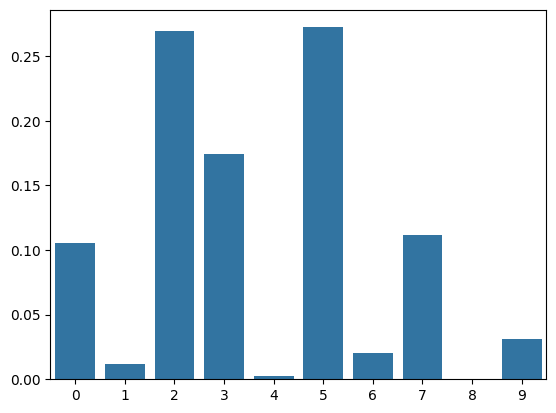

In [97]:
sns.barplot(x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], y=result[0])